In [1]:
import json
import itertools

In [2]:
import numpy as np 
import matplotlib.pyplot as plt

from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot, draw_labels

In [3]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
]

args = DefaultArgumentParser.parse(args=string_args)

In [4]:
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame)
sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449.0
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504.0
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756.0
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138.0
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751.0
...,...,...,...,...,...,...
1709424000,62039.90,63330.90,61339.50,63178.50,200312.503,22965.0
1709510400,63178.50,68600.00,62299.00,68296.40,632882.144,58113.0
1709596800,68296.50,69350.00,59112.00,63747.40,1053025.132,92467.0


In [5]:
df = sdf.copy()
df["roc"] = df.close / df.open - 1
df["csroc"] = np.cumsum(df.roc)
df["scsroc"] = df.csroc.rolling(window=3, min_periods=1, center=True).mean()

df["center-max"] = df.scsroc.rolling(window=7, min_periods=1, center=True).max()
df["center-min"] = df.scsroc.rolling(window=7, min_periods=1, center=True).min()
df["is-fractal"] = (df.scsroc == df["center-max"]) | (df.scsroc == df["center-min"])
df["fractal"] = df.scsroc[df["is-fractal"]]
df["previous-fractal"] = df.fractal.shift(1).ffill()

df["distance"] = np.abs(df["previous-fractal"] - df.fractal).bfill()
df["avg"] = df.distance.rolling(window=100, min_periods=1).mean()
df["label"] = df.avg <= df.distance

print(df.label.value_counts() / len(df))

df

label
False    0.6
True     0.4
Name: count, dtype: float64


,open,high,low,close,volume,trade,roc,csroc,scsroc,center-max,center-min,is-fractal,fractal,previous-fractal,distance,avg,label
timestamp,,,,,,,,,,,,,,,,,
1569456000,8428.15,8464.40,7700.67,8060.15,60065.945,449.0,-0.043663,-0.043663,-0.036559,-0.030028,-0.036559,True,-0.036559,NaN,0.023230,0.023230,True
1569542400,8061.98,8260.00,7851.94,8176.52,40034.653,504.0,0.014207,-0.029456,-0.033494,-0.026120,-0.036559,False,NaN,-0.036559,0.023230,0.023230,True
1569628800,8178.26,8311.00,8001.14,8195.38,33820.919,756.0,0.002093,-0.027362,-0.034445,-0.013329,-0.036559,False,NaN,-0.036559,0.023230,0.023230,True
1569715200,8199.00,8226.35,7888.98,8041.96,35966.056,1138.0,-0.019154,-0.046516,-0.030028,-0.013329,-0.036559,False,NaN,-0.036559,0.023230,0.023230,True
1569801600,8042.08,8331.89,7709.01,8285.84,54412.520,751.0,0.030311,-0.016205,-0.026120,-0.013329,-0.034445,False,NaN,-0.036559,0.023230,0.023230,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1709424000,62039.90,63330.90,61339.50,63178.50,200312.503,22965.0,0.018353,3.036243,3.057127,3.085292,3.015378,False,NaN,2.819214,0.274382,0.108737,True
1709510400,63178.50,68600.00,62299.00,68296.40,632882.144,58113.0,0.081007,3.117250,3.068044,3.093596,3.015378,False,NaN,2.819214,0.274382,0.111324,True
1709596800,68296.50,69350.00,59112.00,63747.40,1053025.132,92467.0,-0.066608,3.050641,3.085292,3.093596,3.026093,False,NaN,2.819214,0.274382,0.112489,True


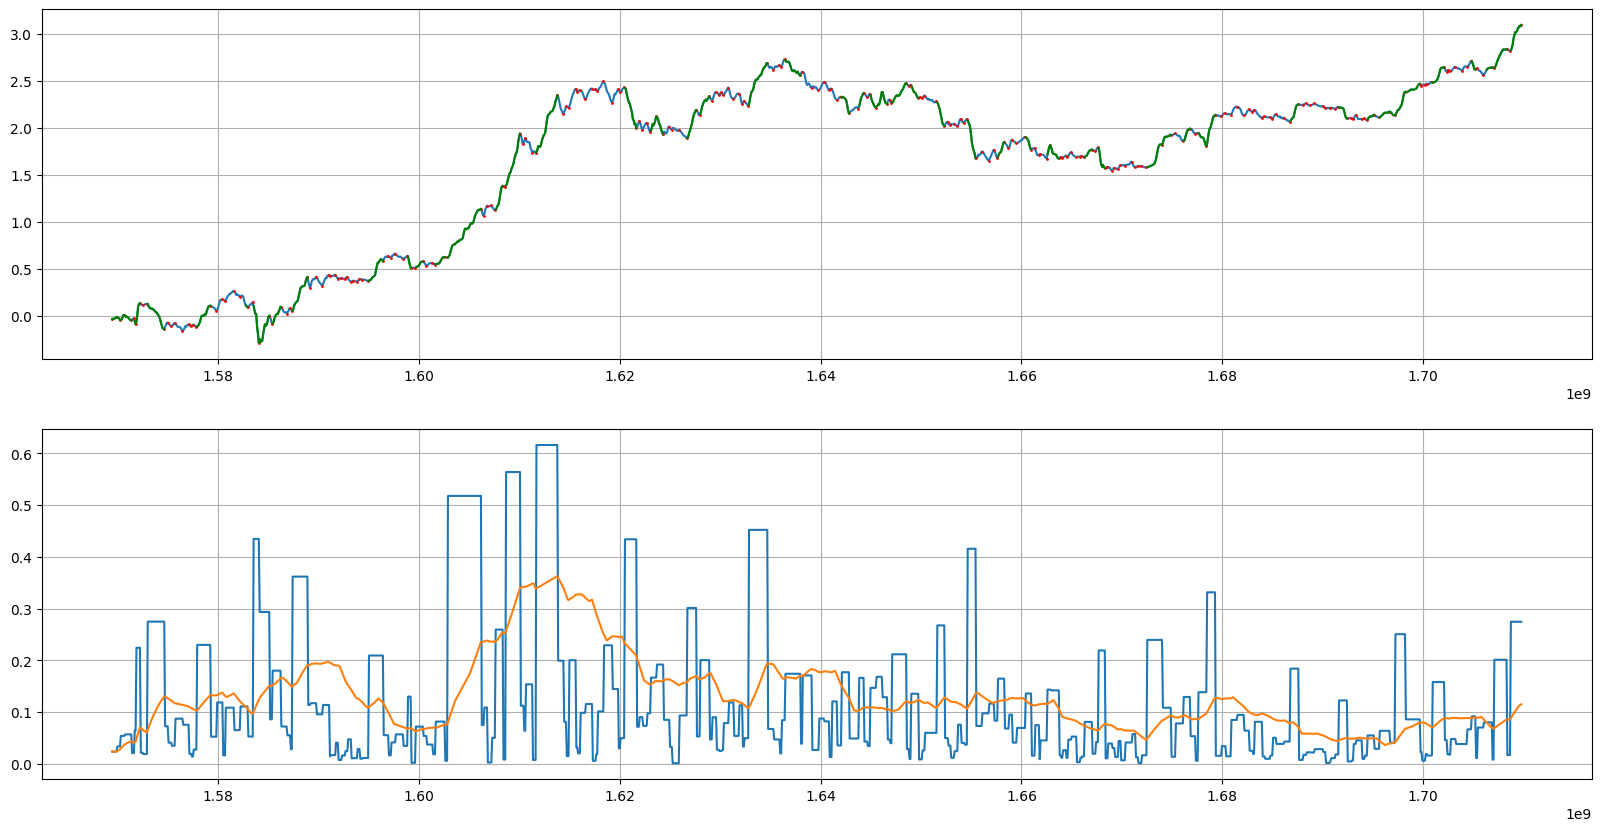

In [6]:
pdf = df.copy()
pdf["regime"] = np.where(pdf.label, pdf.scsroc, np.nan)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 10))

# axs[0].plot(pdf.csroc)
axs[0].plot(pdf.scsroc)
axs[0].plot(pdf.fractal, "ro", markersize=1)
# axs[0].plot(pdf["previous-fractal"], "mo", markersize=1)
axs[0].plot(pdf.regime, "g")
axs[0].grid()

axs[1].plot(pdf.distance)
axs[1].plot(pdf.avg)
axs[1].grid()

/home/sahand/.local/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


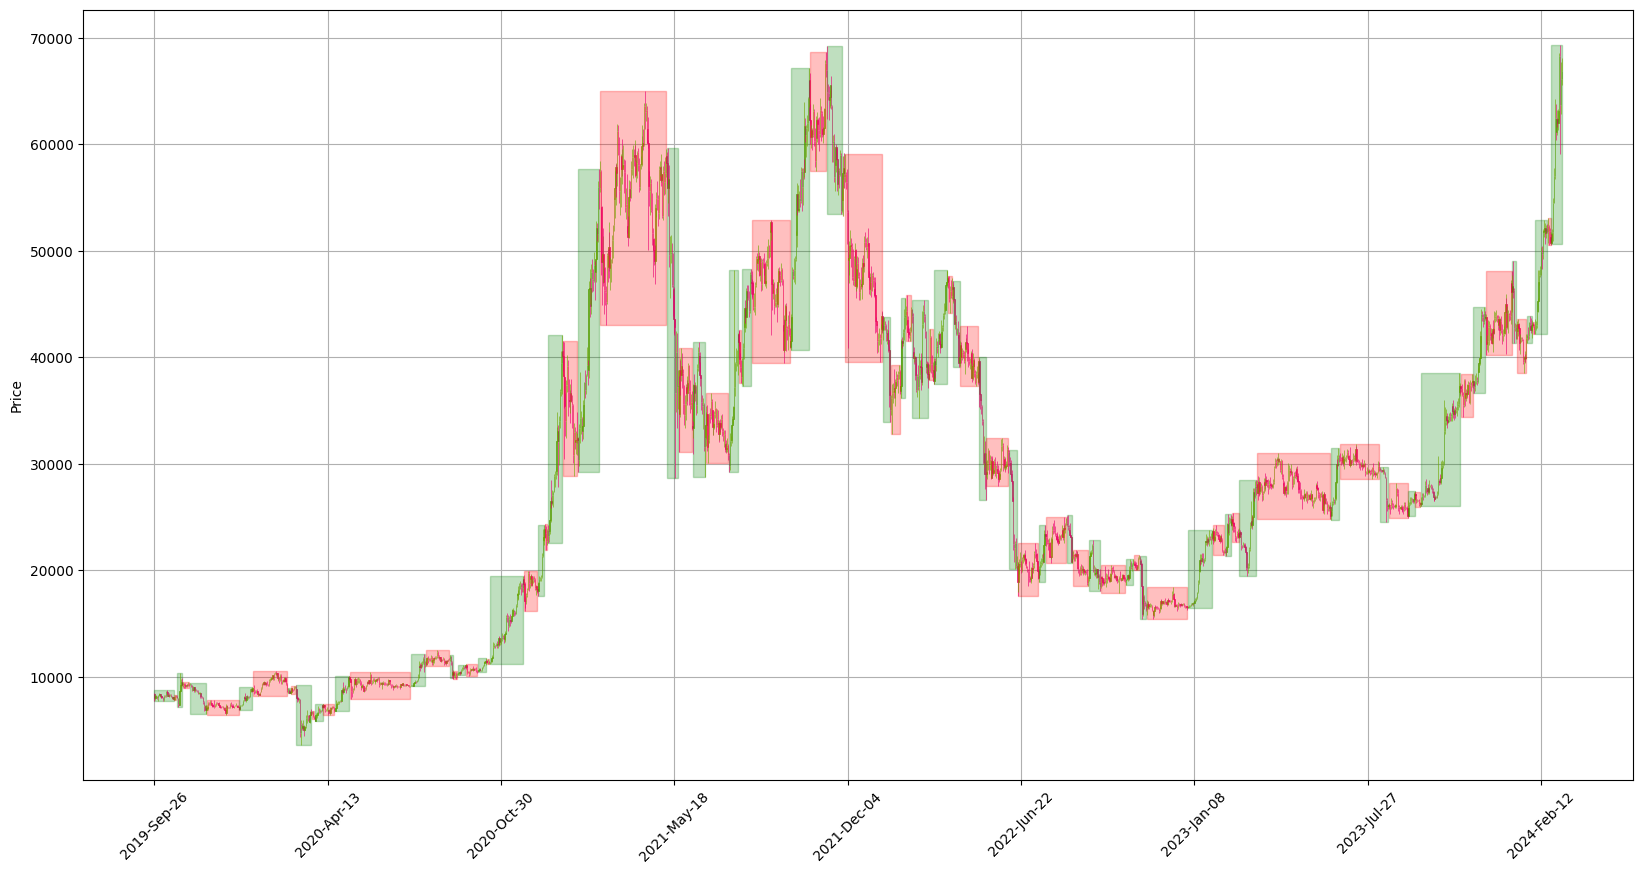

In [7]:
pdf = df.copy()

fig, ohlc_ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))
draw_candlestick_plot(ax=ohlc_ax, df=pdf)
draw_labels(ohlc_ax=ohlc_ax, df=pdf)
ohlc_ax.grid()